# Рекуррентные сети
### 1. Зачем они нужны?

Недостаток сетей прямого распространения - анализ временных последовательностей, анализ траектории движения и текстовой информации. Во всех этих примерах важно знать предыдущие состояния системы.

Рекуррентные сети работаю с последовательностью элементов произвольной длины. Отклик рекуррентной системы - некая функция f от входного значения и предыдущего результата:

$$h_k=f(x_k,h_{k-1})$$

В простом случае $f(x_k,h_{k-1})=\alpha \cdot (x_k + h_{k-1}) = \alpha^3 x_1 + \alpha^2 x_2 + \alpha x_3$

### 2. Рекуррентный слой

Входной сигнал $\overline{x_t}$ умножается вначале на матрицу весовых коэффициентов $\overline{W}$ и результат суммируется с предыдущим выходным значением $\overline{h_{t-1}}$ и добавлением смещений $\overline{b}$:

$$
\overline{a_t}=\overline{W} \cdot \overline{x_t} + \overline{h_{t-1}} + \overline{b}
$$

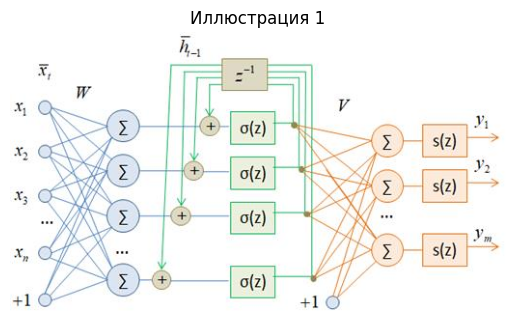

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image1 = mpimg.imread('illustrations/RNN.jpg')

plt.imshow(image1)
plt.axis('off')
plt.title('Иллюстрация 1')
plt.show()

Затем, вектор $\overline{a_t}$ пропускается через функцию активации $\sigma(z)$ и формируется вектор $\overline{h_t}$:

$$
\overline{h_t}=\sigma(\overline{a_t})
$$

### 3. Формат выборки для прогнозирования символов

Для каждых предыдущих prev_chars символов сеть должна формировать прогноз текущего символа. В результате получаем следующий набор входных векторов и целевых значений:

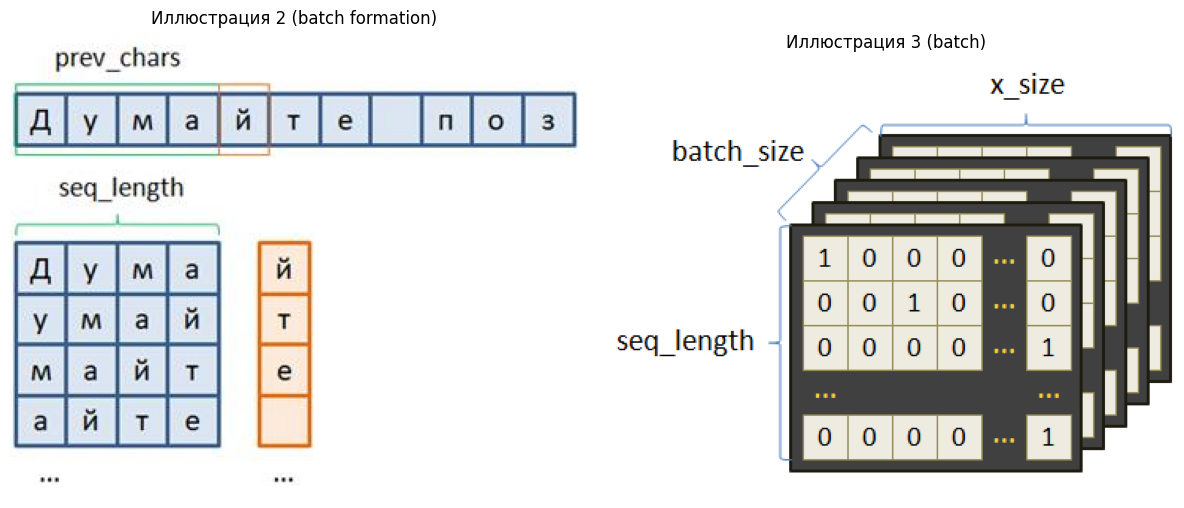

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image2 = mpimg.imread('illustrations/RNN_batch_formation.jpg')
image3 = mpimg.imread('illustrations/RNN_batch.jpg')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(image2)
ax1.axis('off')
ax1.set_title('Иллюстрация 2 (batch formation)')

ax2.imshow(image3)
ax2.axis('off')
ax2.set_title('Иллюстрация 3 (batch)')

plt.tight_layout()
plt.show()

На выходе формироваться прогнозируемое значение. Получаем модель вида Many-to-One. В виде слоя это выглядит следующим образом:

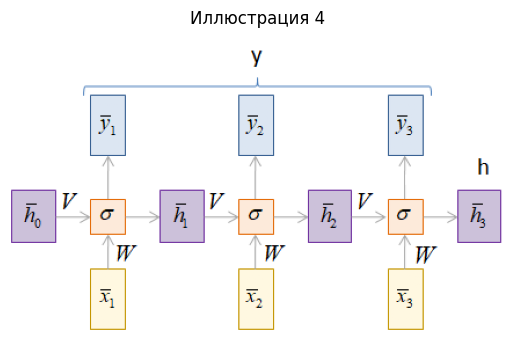

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image4 = mpimg.imread('illustrations/RNN_layer.jpg')

plt.imshow(image4)
plt.axis('off')
plt.title('Иллюстрация 4')
plt.show()

In [4]:
import torch
import torch.nn as nn

rnn = nn.RNN(33, 64, batch_first=True)

x = torch.randn(8, 3, 33)
h0 = torch.randn(1, 8, 64)
y, h = rnn(x, h0)

print(f'y:{y.size()}')
print(f'h:{h.size()}')

y:torch.Size([8, 3, 64])
h:torch.Size([1, 8, 64])
